# 05 · 무작위성 배터리 — 이 수열은 정말 무작위인가?

> Part 5 · *RNG 감사관이 쓰는 도구로 로또 스트림을 검사한다.*

하나의 검정만으로 "무작위다"라고 결론내리면 안 됩니다. 각 검정은 **특정 종류의 구조**에만 민감하기
때문입니다. 그래서 암호학·카지노·난수 감사에서는 **배터리(battery)**를 돌립니다. 이 노트북은 그
교육용 축소판입니다.

| 검정 | 무엇을 잡아내나 | 무작위면 |
|---|---|---|
| 샤논 엔트로피 | 정보량이 최대(log₂45)인가 | 효율 ≈ 1 |
| 2-표본 KS | 전·후반 분포가 같은가 (드리프트) | p 큼 |
| Anderson–Darling | 합계가 정규인가 (CLT) | 기각 안 함 |
| ADF | 시계열이 정상인가 | **기각**(정상) |
| 직렬 χ² | 직전 회차가 다음을 예측하나 | p 큼 |
| 순열 스펙트럼 | 숨은 주기가 있나 | p 큼 |

⚠️ **핵심 주의**: 검정마다 "무작위 친화적" 방향이 다릅니다. 대부분은 *큰 p*가 무작위지만, ADF는
귀무가설이 "단위근(비정상)"이라 *작은 p*(기각)가 무작위입니다. 방향을 섞으면 표를 거꾸로 읽게 됩니다.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.lotto_ds import viz, randomness as rd
from src.lotto_ds.cleaning import load_clean, WIN_COLS

viz.apply_style()
draws = load_clean("draws")

## 배터리 실행

In [2]:
battery = rd.run_battery(draws)
battery[["test", "statistic", "p_value", "random_consistent"]]

C:\Users\simpl\pro\3004_lot\src\lotto_ds\randomness.py:87: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(_sums(draws), dist="norm")


,test,statistic,p_value,random_consistent
0,샤논 엔트로피 효율 (entropy efficiency),0.999,0.9718,True
1,전·후반 분포 동일성 (two-sample KS drift),0.031,0.9312,True
2,Anderson–Darling 정규성 (sum normality),0.441,0.5000,True
3,ADF 정상성 (stationarity),-12.134,0.0000,True
4,직렬 종속 (lag-1 parity χ²),1.094,0.2956,True
5,스펙트럼 최대 봉우리 (permutation spectral),0.020,0.0020,False


## 결과 시각화 — 무작위 부합 여부
초록 = 무작위와 부합, 빨강 = 부합하지 않음.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


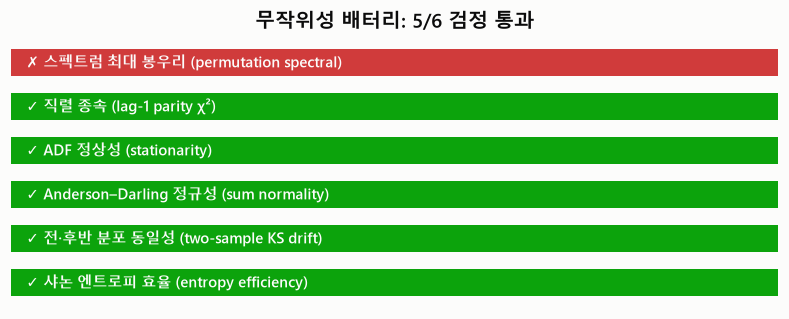

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.2))
labels = battery["test"].tolist()
consistent = battery["random_consistent"].tolist()
colors = [viz.STATUS["good"] if c else viz.STATUS["critical"] for c in consistent]
ax.barh(range(len(labels)), [1]*len(labels), color=colors, height=0.6)
for i, (lab, c) in enumerate(zip(labels, consistent)):
    ax.text(0.02, i, ("✓ " if c else "✗ ") + lab, va="center", ha="left",
            color=viz.INK["surface"], fontsize=10, fontweight="600")
ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_xticks([])
ax.set_title(f"무작위성 배터리: {sum(consistent)}/{len(consistent)} 검정 통과")
for sp in ax.spines.values(): sp.set_visible(False)
viz.savefig(fig, "05_battery.png"); plt.show()

## 유일하게 걸린 검정 — 순열 스펙트럼
스펙트럼 검정이 작은 주기 성분을 잡아냅니다(p≈0.002). 이것이 진짜 신호일까요? 세 가지로 따집니다.

In [4]:
# 1) 효과 크기: 최대 봉우리가 차지하는 파워 비율
s = draws[WIN_COLS].to_numpy(int).sum(axis=1).astype(float)
s = s - s.mean()
power = np.abs(np.fft.rfft(s))[1:]**2
g = power.max()/power.sum()
print(f"최대 봉우리 파워 비율 g = {g:.4f}  → 전체 파워의 {g*100:.2f}%만 설명 (사실상 평평)")

# 2) 검정의 보정(calibration): 합성 무작위 데이터에서 p가 균등한지
rng = np.random.default_rng(7)
syn_p = []
for i in range(30):
    m = np.array([np.sort(rng.choice(range(1,46),6,replace=False)) for _ in range(800)])
    d = pd.DataFrame({f"win{j+1}": m[:,j] for j in range(6)})
    syn_p.append(rd.spectral_permutation(d, n_perm=300, seed=i).p_value)
syn_p = np.array(syn_p)
print(f"합성 무작위에서 스펙트럼 p: 중앙값 {np.median(syn_p):.2f}, p<0.05 비율 {np.mean(syn_p<0.05):.2f}"
      f"  → 검정은 올바르게 보정됨(≈5%)")

최대 봉우리 파워 비율 g = 0.0200  → 전체 파워의 2.00%만 설명 (사실상 평평)


합성 무작위에서 스펙트럼 p: 중앙값 0.51, p<0.05 비율 0.07  → 검정은 올바르게 보정됨(≈5%)


### ACF와의 연결 (스펙트럼 ↔ 자기상관은 푸리에 쌍대)
이 작은 봉우리는 04번에서 본 미세한 lag-10 자기상관(|acf|≈0.07)의 **주파수 영역 그림자**입니다.
같은 무의미한 잡음을 시간축(ACF)과 주파수축(스펙트럼)에서 각각 본 것뿐입니다.

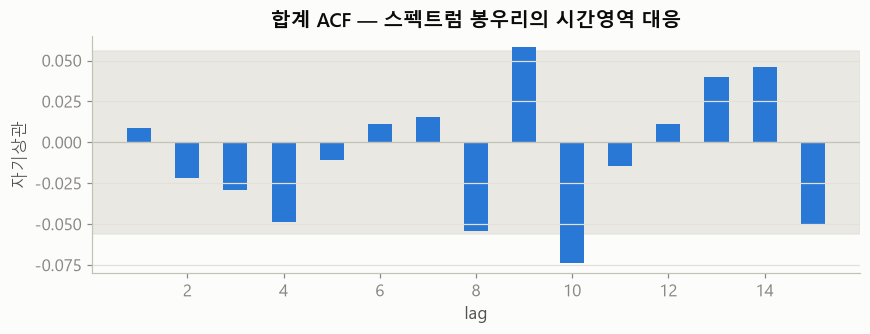

In [5]:
from statsmodels.tsa.stattools import acf
a = acf(s, nlags=15, fft=False)[1:]
fig, ax = plt.subplots(figsize=(9, 2.8))
conf = 1.96/np.sqrt(len(s))
ax.bar(range(1,16), a, color=viz.CAT[0], width=0.5)
ax.axhspan(-conf, conf, color=viz.INK["grid"], alpha=0.7, zorder=0)
ax.axhline(0, color=viz.INK["baseline"], lw=0.8)
ax.set_title("합계 ACF — 스펙트럼 봉우리의 시간영역 대응")
ax.set_xlabel("lag"); ax.set_ylabel("자기상관")
viz.savefig(fig, "05_acf_link.png"); plt.show()

⚠️ **흔한 함정**: 배터리에서 하나가 유의하면 "구조 발견!"이라 외치기 쉽습니다. 하지만 (1) 효과크기가
무의미하고, (2) 여러 검정 중 하나쯤 우연히 걸리는 게 정상이며(다중검정), (3) 다른 방법과 교차확인하면
같은 잡음임을 알 수 있습니다. **하나의 p값이 아니라 증거의 총합**으로 판단하세요.

### 정리
- 6개 검정 중 5개가 무작위와 완전히 부합, 1개(스펙트럼)는 무의미한 미세 봉우리.
- 그 봉우리는 04번의 lag-10 자기상관과 동일한 현상 — 예측에 쓸 수 없음.
- 다음: **06 · 베이지안** — 각 번호의 진짜 확률을 불확실성과 함께 추정.